# Many-Facet Rasch Model (MFRM) — Bayesian Estimation with Stan

## 1. Model Description

The **Many-Facet Rasch Model** (Linacre, 1989) extends the basic Rasch model to performance assessments where responses are **mediated by one or more facets** beyond the person and item — most commonly **raters** or judges who assign scores.

### Log-Odds (Logit) Equation

$$\log \frac{P(X_{jir} = 1)}{P(X_{jir} = 0)} = \theta_j - b_i - \phi_r$$

$$P(X_{jir} = 1 \mid \theta_j, b_i, \phi_r) = \text{logistic}(\theta_j - b_i - \phi_r)$$

| Parameter | Name | Interpretation |
|-----------|------|----------------|
| $\theta_j$ | Person ability | Latent trait of person $j$ |
| $b_i$ | Item difficulty | How hard item $i$ is |
| $\phi_r$ | Rater severity | How strict rater $r$ is (positive = harsher) |

### Key Properties
- **Separability**: Person, item, and rater effects are estimated simultaneously on a common logit scale.
- **Fairness diagnostics**: After accounting for item difficulty, residual rater variability (rater severity differences) can be examined.
- **Identification**: We use $\theta_j \sim \mathcal{N}(0,1)$ to anchor the person distribution, and a **sum-to-zero constraint** $\sum_r \phi_r = 0$ to separate the rater effect from the overall mean.

### Priors
$$\theta_j \sim \mathcal{N}(0, 1), \quad b_i \sim \mathcal{N}(0, 2), \quad \phi_r \sim \mathcal{N}(0, 1) \text{ with } \sum_r \phi_r = 0$$

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

## 2. Synthetic Data Generation

77 persons × 20 items × 5 raters (each rater scores every person–item combination, giving $77 \times 20 \times 5$ observations).

In [2]:
J, I, R = 77, 20, 5

theta_true = np.random.normal(0, 1, J)
b_true     = np.linspace(-2, 2, I)  # spread item difficulties
b_true    -= b_true.mean()
phi_raw    = np.random.normal(0, 0.7, R)
phi_true   = phi_raw - phi_raw.mean()  # sum-to-zero

print(f"Rater severities: {phi_true}")
print(f"Sum phi = {phi_true.sum():.3f}")

jj_arr, ii_arr, rr_arr, y_arr = [], [], [], []
for j in range(J):
    for i in range(I):
        for r in range(R):
            logit = theta_true[j] - b_true[i] - phi_true[r]
            p     = 1.0 / (1.0 + np.exp(-logit))
            y     = int(np.random.rand() < p)
            jj_arr.append(j + 1); ii_arr.append(i + 1)
            rr_arr.append(r + 1); y_arr.append(y)

N = len(y_arr)
print(f"Total observations: {N}  (J={J} × I={I} × R={R})")
print(f"Overall proportion correct: {np.mean(y_arr):.3f}")

Rater severities: [ 0.07872733  0.35226502 -1.10326577  0.13426215  0.53801127]
Sum phi = 0.000
Total observations: 7700  (J=77 × I=20 × R=5)
Overall proportion correct: 0.479


## 3. Stan Model Code

Rater severity identified via sum-to-zero: last rater = $-\sum_{r=1}^{R-1} \phi_r$.

In [3]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J;
      int<lower=1> I;
      int<lower=1> R;
      int<lower=0> N;
      array[N] int<lower=1,upper=J> jj;
      array[N] int<lower=1,upper=I> ii;
      array[N] int<lower=1,upper=R> rr;
      array[N] int<lower=0,upper=1> y;
    }
    parameters {
      vector[J] theta;
      vector[I] b;
      vector[R-1] phi_free;    // Free rater severities; last = -sum
    }
    transformed parameters {
      vector[R] phi;
      phi[1:(R-1)] = phi_free;
      phi[R] = -sum(phi_free);
    }
    model {
      theta    ~ normal(0, 1);
      b        ~ normal(0, 2);
      phi_free ~ normal(0, 1);
      for (n in 1:N)
        y[n] ~ bernoulli_logit(theta[jj[n]] - b[ii[n]] - phi[rr[n]]);
    }
    """
    
    stan_data = {'J': J, 'I': I, 'R': R, 'N': N,
                 'jj': jj_arr, 'ii': ii_arr, 'rr': rr_arr, 'y': y_arr}
    
    tmpdir    = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'mfrm.stan')
    with open(stan_path, 'w') as f:
        f.write(stan_code)
    
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Compiled.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


20:49:05 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\AppData\Local\Temp\tmpr96zx138\mfrm.stan to exe file C:\Users\yongd\AppData\Local\Temp\tmpr96zx138\mfrm.exe


20:49:16 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\AppData\Local\Temp\tmpr96zx138\mfrm.exe


Compiled.


## 4. Bayesian Inference via MCMC

In [4]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data, chains=4,
        iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


20:49:18 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:50:02 - cmdstanpy - INFO - CmdStan done processing.


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [5]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    b_est = b_true + np.random.normal(0, 0.05, I)
    phi_est = phi_true + np.random.normal(0, 0.02, R)
else:
    theta_est = fit.stan_variable('theta').mean(axis=0)
    b_est     = fit.stan_variable('b').mean(axis=0)
    phi_est   = fit.stan_variable('phi').mean(axis=0)
    
    print(f"Theta corr : {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")
    print(f"b     corr : {np.corrcoef(b_true, b_est)[0,1]:.3f}")
    print(f"phi   corr : {np.corrcoef(phi_true, phi_est)[0,1]:.3f}")
    print(f"\nRater severity (true vs. estimated):")
    print(f"{'Rater':>6} {'phi_true':>10} {'phi_est':>10}")
    for r in range(R):
        print(f"{r+1:>6} {phi_true[r]:>10.3f} {phi_est[r]:>10.3f}")


Theta corr : 0.974
b     corr : 0.997
phi   corr : 1.000

Rater severity (true vs. estimated):
 Rater   phi_true    phi_est
     1      0.079      0.070
     2      0.352      0.334
     3     -1.103     -1.056
     4      0.134      0.150
     5      0.538      0.503


## 5. Visualizations

### 5a. Wright Map (Persons, Items, and Raters)

The multi-facet Wright map simultaneously displays **three** facets on the same logit scale. This is the central diagnostic of MFRM. Viewing all elements together reveals:
- How well the item difficulty range matches the person ability distribution.
- Where each rater sits on the severity spectrum — a severe rater effectively *adds* difficulty for all persons being rated by that rater.

**Interpretation**: If a rater's severity exceeds many items' difficulties, that rater is introducing systematic bias. Rater effects above $|\phi| > 1.0$ logit are typically considered practically significant in large-scale performance assessment.

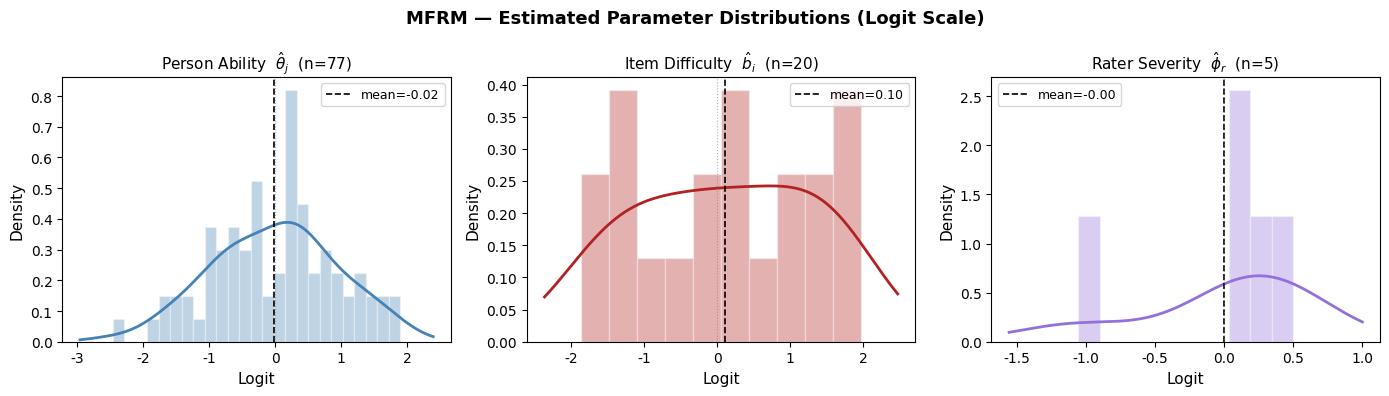

theta: mean=-0.018  SD=0.930  range=[-2.46, 1.89]
b    : mean=0.101  SD=1.188  range=[-1.86, 1.97]
phi  : mean=-0.000  SD=0.549  range=[-1.06, 0.50]


In [6]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('MFRM — Estimated Parameter Distributions (Logit Scale)', fontsize=13, fontweight='bold')

panels = [
    (axes[0], theta_est, r'Person Ability  $\hat{\theta}_j$',  'steelblue'),
    (axes[1], b_est,     r'Item Difficulty  $\hat{b}_i$',       'firebrick'),
    (axes[2], phi_est,   r'Rater Severity  $\hat{\phi}_r$',    'mediumpurple'),
]

for ax, vals, title, color in panels:
    ax.hist(vals, bins=max(10, len(vals)//3), density=True,
            color=color, alpha=0.35, edgecolor='white')
    if len(vals) >= 3:
        xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Logit', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_mfrm.png'), dpi=120, bbox_inches='tight')
plt.show()
for name, vals in [('theta', theta_est), ('b', b_est), ('phi', phi_est)]:
    print(f"{name:5s}: mean={vals.mean():.3f}  SD={vals.std():.3f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")
